# Harry Potter Knowledge Graph — Projet de webdatamining

## Installation & Imports des bibliothèques


In [1]:
!pip install rdflib requests spacy owlready2 pykeen torch \
    scikit-learn matplotlib seaborn pandas numpy tqdm
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 92.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os, re, json, time, logging, warnings
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from owlready2 import *
from rdflib import Graph, URIRef, Literal, Namespace, RDF, RDFS, OWL, XSD
from rdflib.namespace import SKOS

import spacy
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

# Création de l'arborescence projet
for d in ['data/samples', 'kg_artifacts', 'reports', 'models', 'src']:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## Data Acquisition via le Wikidata sur Harry Potter


In [12]:
WIKIDATA_SPARQL = "https://query.wikidata.org/sparql"
HEADERS = {"User-Agent": "HPProject/1.0"}

QUERIES = {
    "series": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?book wdt:P179 wd:Q8337 .
          ?char wdt:P1441 ?book .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "hogwarts": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?char wdt:P69 wd:Q25975 .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "universe": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?char wdt:P1080 wd:Q5410773 .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "manual": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          VALUES ?char {
            wd:Q3244512 wd:Q180659 wd:Q184805 wd:Q170687 wd:Q174904
            wd:Q174921 wd:Q217246 wd:Q229054 wd:Q236306 wd:Q260819
            wd:Q264983 wd:Q273930 wd:Q274466 wd:Q294927 wd:Q312965
            wd:Q313226 wd:Q355566 wd:Q359457 wd:Q382274 wd:Q392049
            wd:Q435651 wd:Q464118 wd:Q700705 wd:Q734209 wd:Q850756
            wd:Q866225 wd:Q936765 wd:Q975871 wd:Q1043120 wd:Q1124106
            wd:Q1183173 wd:Q1230184 wd:Q1397671 wd:Q1421901 wd:Q1525851
            wd:Q1574844 wd:Q1637868 wd:Q1682310 wd:Q1770841 wd:Q1972781
            wd:Q2099744 wd:Q2265598 wd:Q2380867 wd:Q2674728 wd:Q2737248
            wd:Q3221958 wd:Q3271644 wd:Q4973503 wd:Q5256612 wd:Q7374115
          }
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        }
    """,
}

rows = {}
for name, q in QUERIES.items():
    try:
        resp = requests.get(WIKIDATA_SPARQL,
                            params={"query": q, "format": "json"},
                            headers=HEADERS, timeout=60)
        bindings = resp.json()["results"]["bindings"]
        count = 0
        for b in bindings:
            qid    = b["char"]["value"].split("/")[-1]
            label  = b.get("charLabel", {}).get("value", "")
            gender = b.get("genderLabel", {}).get("value", "")
            if label and not label.startswith("Q") and qid not in rows:
                rows[qid] = {"wd_id": qid, "label": label, "gender": gender}
                count += 1
        print(f"  [{name}] +{count} characters")
    except Exception as e:
        print(f"  [{name}] error : {e}")

df_chars = pd.DataFrame(list(rows.values()))
print(f"\n df_chars total : {len(df_chars)} characters")
print(df_chars[["label","wd_id","gender"]].head(15))

  [series] +78 characters
  [hogwarts] +0 characters
  [universe] +256 characters
  [manual] +40 characters

 df_chars total : 374 characters
                   label       wd_id  gender
0        Ottaline Gambol   Q65404660  female
1         Vernon Dursley   Q11910388    male
2    James Sirius Potter    Q9010722    male
3        Delphini Riddle   Q26203901  female
4         Dudley Dursley    Q5700415    male
5       Albus Dumbledore     Q712548    male
6                  kappa     Q335140        
7           Harry Potter    Q3244512    male
8   Hugo Granger-Weasley    Q3741059    male
9         Barnabas Cuffe   Q21502388    male
10         Eldred Worple  Q106392724    male
11      Dolores Umbridge     Q716941  female
12  Rose Granger-Weasley    Q3744404  female
13      Lily Luna Potter    Q3745681  female
14          Sirius Black     Q713701    male


## Creation of the different classes

In [ ]:
def sparql(query, timeout=60):
    try:
        r = requests.get(WIKIDATA_SPARQL,
                         params={"query": query, "format": "json"},
                         headers=HEADERS, timeout=timeout)
        return r.json()["results"]["bindings"]
    except Exception as e:
        print(f"erreur SPARQL : {e}")
        return []

def val(row, key):
    return row.get(key, {}).get("value", None)

def qid(uri):
    return uri.split("/")[-1] if uri and uri.startswith("http") else uri

# Livres
Q_BOOKS = """
SELECT DISTINCT ?item ?itemLabel ?pubDate ?pages WHERE {
  ?item wdt:P179 wd:Q8337 .
  OPTIONAL { ?item wdt:P577 ?pubDate }
  OPTIONAL { ?item wdt:P1104 ?pages }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
}
"""
raw_books = sparql(Q_BOOKS)
df_books = pd.DataFrame([{
    "wd_id" : qid(val(r, "item")),
    "label" : val(r, "itemLabel"),
    "pubDate": val(r, "pubDate"),
    "pages" : val(r, "pages"),
} for r in raw_books]).drop_duplicates("wd_id")

# Famille
REL_LABELS = {"P22":"hasFather","P25":"hasMother","P26":"hasSpouse",
              "P3373":"hasSibling","P40":"hasChild"}
Q_FAMILY = """
SELECT DISTINCT ?person ?personLabel ?relType ?target ?targetLabel WHERE {
  VALUES ?relType { wdt:P22 wdt:P25 wdt:P26 wdt:P3373 wdt:P40 }
  ?person ?relType ?target .
  ?person wdt:P1080 wd:Q5410773 .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
} LIMIT 2000
"""
raw_family = sparql(Q_FAMILY)
df_family = pd.DataFrame([{
    "subject"      : qid(val(r, "person")),
    "subject_label": val(r, "personLabel"),
    "relation"     : REL_LABELS.get(val(r, "relType",).split("/")[-1] if val(r,"relType") else "", "relatedTo"),
    "object"       : qid(val(r, "target")),
    "object_label" : val(r, "targetLabel"),
} for r in raw_family]).drop_duplicates()

# Maisons
Q_HOUSES = """
SELECT DISTINCT ?item ?itemLabel ?founderLabel WHERE {
  VALUES ?item { wd:Q170534 wd:Q170547 wd:Q170548 wd:Q170546 }
  OPTIONAL { ?item wdt:P112 ?founder }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
}
"""
raw_houses = sparql(Q_HOUSES)
df_houses = pd.DataFrame([{
    "wd_id"  : qid(val(r, "item")),
    "label"  : val(r, "itemLabel"),
    "founder": val(r, "founderLabel"),
} for r in raw_houses]).drop_duplicates("wd_id")

# Appartenances aux maisons 
Q_MEMBERSHIPS = """
SELECT DISTINCT ?person ?personLabel ?houseLabel WHERE {
  VALUES ?house { wd:Q170534 wd:Q170547 wd:Q170548 wd:Q170546 }
  { ?person wdt:P361 ?house } UNION { ?person wdt:P1080 wd:Q5410773 . ?person wdt:P361 ?house }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
} LIMIT 1000
"""
raw_memberships = sparql(Q_MEMBERSHIPS)
df_memberships = pd.DataFrame([{
    "person_id"   : qid(val(r, "person")),
    "person_label": val(r, "personLabel"),
    "house_label" : val(r, "houseLabel"),
} for r in raw_memberships]).drop_duplicates()

print(f"DataFrames built")
print(f"  Characters : {len(df_chars)}")
print(f"  Books      : {len(df_books)}")
print(f"  Relations   : {len(df_family)}")
print(f"  Houses     : {len(df_houses)}")
print(f"  Memberships: {len(df_memberships)}")


DataFrames construits
  Personnages : 376
  Livres      : 10
  Relations   : 518
  Maisons     : 4
  Appartenances: 0


## NER (Named Entity Recognition) with spaCy

In [11]:
nlp = spacy.load("en_core_web_sm")

TEXTS = [
    "Harry Potter is the main character. He attends Hogwarts School of Witchcraft and Wizardry.",
    "Albus Dumbledore is the headmaster of Hogwarts and leads the Order of the Phoenix.",
    "Hermione Granger, Ron Weasley and Harry Potter are best friends in Gryffindor house.",
    "Lord Voldemort, also known as Tom Riddle, is the main antagonist of the series.",
    "Professor Severus Snape teaches Potions at Hogwarts and is head of Slytherin.",
    "Draco Malfoy is a student in Slytherin and Harry Potter's rival.",
    "Sirius Black escaped from Azkaban prison and is Harry Potter's godfather.",
    "Rubeus Hagrid is the Keeper of Keys and Grounds at Hogwarts.",
    "Bellatrix Lestrange is a Death Eater and loyal follower of Voldemort.",
    "Neville Longbottom becomes an important member of Dumbledore's Army.",
]

all_entities = []
for text in TEXTS:
    doc = nlp(text)
    for ent in doc.ents:
        all_entities.append({
            "text" : ent.text,
            "label": ent.label_,
            "start": ent.start_char,
            "end"  : ent.end_char,
            "context": text[:80]
        })

df_ner = pd.DataFrame(all_entities)
print(f"{len(df_ner)} extracted entities")
print(df_ner.groupby("label")["text"].apply(list))

27 extracted entities
label
FAC            [the Keeper of Keys and Grounds at Hogwarts]
GPE              [Phoenix, Gryffindor, Neville, Longbottom]
LOC                                             [Voldemort]
NORP                                              [Azkaban]
ORG       [Hogwarts School of Witchcraft, Wizardry, Albu...
PERSON    [Harry Potter, Hogwarts, Hermione Granger, Ron...
Name: text, dtype: object


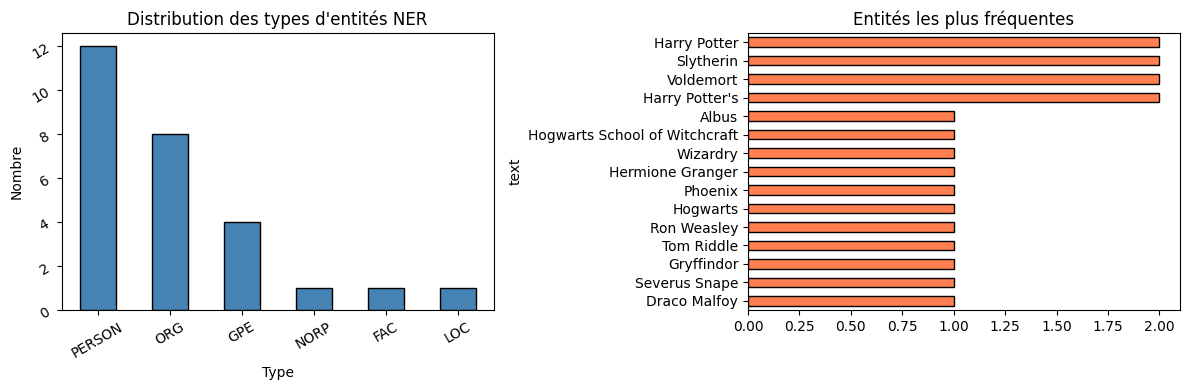

 NER graph saved


In [10]:
# view of the NER distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des types
df_ner["label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution des types d'entités NER")
axes[0].set_xlabel("Type"); axes[0].set_ylabel("Nombre")
axes[0].tick_params(rotation=30)

top_ents = df_ner["text"].value_counts().head(15)
top_ents.plot(kind="barh", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Entités les plus fréquentes")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("reports/ner_analysis.png", dpi=150)
plt.show()
print(" NER graph saved")

In [18]:
#  cases of ambiguity 
ambiguity_cases = {
    "Case 1 — Dumbledore (PERSON vs ORG)": {
        "description": ("'Dumbledore' is tagged as PERSON in 'Dumbledore speaks', "
                        "but in 'the Dumbledore era' it could be ORG."),
        "resolution": "We prioritize PERSON because it's a fictional entity identified in Wikidata (Q190050)."
    },
    "Case 2 — Voldemort / Tom Riddle (coreference)": {
        "description": ("Two different names refer to the same character. "
                        "spaCy treats them as two distinct entities."),
        "resolution": "We align them via owl:sameAs in Wikidata (same QID: Q182942)."
    },
    "Case 3 — Gryffindor (ORG vs LOC)": {
        "description": ("'Gryffindor' is sometimes an organization (house), "
                        "and sometimes a room/location in Hogwarts."),
        "resolution": "We create the class hp:House, a subclass of ORG, and add the property hp:locatedIn."
    },
}

for case, info in ambiguity_cases.items():
    print(f"\n")
    print(f"{case}")
    print(f"   Problem   : {info['description']}")
    print(f"   Resolution : {info['resolution']}")



Case 1 — Dumbledore (PERSON vs ORG)
   Problem   : 'Dumbledore' is tagged as PERSON in 'Dumbledore speaks', but in 'the Dumbledore era' it could be ORG.
   Resolution : We prioritize PERSON because it's a fictional entity identified in Wikidata (Q190050).


Case 2 — Voldemort / Tom Riddle (coreference)
   Problem   : Two different names refer to the same character. spaCy treats them as two distinct entities.
   Resolution : We align them via owl:sameAs in Wikidata (same QID: Q182942).


Case 3 — Gryffindor (ORG vs LOC)
   Problem   : 'Gryffindor' is sometimes an organization (house), and sometimes a room/location in Hogwarts.
   Resolution : We create the class hp:House, a subclass of ORG, and add the property hp:locatedIn.


## building of the knowledge graph

In [19]:
#  Namespaces 
HP  = Namespace("http://harrypotter.org/ontology#")
HPR = Namespace("http://harrypotter.org/resource#")
WD  = Namespace("http://www.wikidata.org/entity/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")

g = Graph()
g.bind("hp",   HP)
g.bind("hpr",  HPR)
g.bind("wd",   WD)
g.bind("wdt",  WDT)
g.bind("owl",  OWL)
g.bind("rdfs", RDFS)
g.bind("xsd",  XSD)
g.bind("skos", SKOS)

#  definition of the ontology (classes) 
CLASSES = {
    "Character" : None,
    "Wizard"    : "Character",
    "Muggle"    : "Character",
    "HalfBlood" : "Character",
    "House"     : None,
    "Book"      : None,
    "Spell"     : None,
    "School"    : None,
    "Artifact"  : None,
}

for cls, parent in CLASSES.items():
    uri = HP[cls]
    g.add((uri, RDF.type, OWL.Class))
    g.add((uri, RDFS.label, Literal(cls, lang="en")))
    if parent:
        g.add((uri, RDFS.subClassOf, HP[parent]))

#  definition of the ontology (properties) 
OBJECT_PROPS = [
    ("memberOf",  "Character", "House"),
    ("hasFather", "Character", "Character"),
    ("hasMother", "Character", "Character"),
    ("hasSpouse", "Character", "Character"),
    ("hasSibling","Character", "Character"),
    ("hasChild",  "Character", "Character"),
    ("appearsIn", "Character", "Book"),
    ("attendsSchool","Character","School"),
    ("learnedSpell","Character","Spell"),
]
DATA_PROPS = [
    ("birthYear", "Character", XSD.integer),
    ("gender",    "Character", XSD.string),
    ("pageCount", "Book",      XSD.integer),
    ("pubYear",   "Book",      XSD.integer),
]

for name, domain, range_ in OBJECT_PROPS:
    uri = HP[name]
    g.add((uri, RDF.type, OWL.ObjectProperty))
    g.add((uri, RDFS.domain, HP[domain]))
    g.add((uri, RDFS.range,  HP[range_]))

for name, domain, xsd_type in DATA_PROPS:
    uri = HP[name]
    g.add((uri, RDF.type, OWL.DatatypeProperty))
    g.add((uri, RDFS.domain, HP[domain]))
    g.add((uri, RDFS.range,  xsd_type))

print(f" Ontology defined : {len(g)} triplets")

 Ontology defined : 60 triplets


In [20]:
def slugify(label: str) -> str:
    """transform a string into a slug suitable for URIs (e.g. "Harry Potter" -> "Harry_Potter")"""
    if not label:
        return "Unknown"
    s = re.sub(r'[^a-zA-Z0-9_]', '_', label.strip())
    return re.sub(r'_+', '_', s).strip('_')

#  adding known houses with owl:sameAs to Wikidata 
KNOWN_HOUSES = {
    "Gryffindor": "Q170534",
    "Slytherin" : "Q170547",
    "Hufflepuff": "Q170548",
    "Ravenclaw" : "Q170546",
}
for name, qid in KNOWN_HOUSES.items():
    uri = HPR[slugify(name)]
    g.add((uri, RDF.type,    HP.House))
    g.add((uri, RDFS.label,  Literal(name, lang="en")))
    g.add((uri, OWL.sameAs,  WD[qid]))

#  adding characters 
char_uris = {}
for _, row in df_chars.iterrows():
    if not row["label"] or pd.isna(row["label"]):
        continue
    uri = HPR[slugify(row["label"])]
    char_uris[row["wd_id"]] = uri

    g.add((uri, RDF.type,    HP.Wizard))
    g.add((uri, RDFS.label,  Literal(row["label"], lang="en")))
    g.add((uri, OWL.sameAs,  WD[row["wd_id"]]))

    if row.get("gender"):
        g.add((uri, HP.gender, Literal(row["gender"])))
    if row.get("birthYear"):
        try:
            g.add((uri, HP.birthYear, Literal(int(float(row["birthYear"])), datatype=XSD.integer)))
        except:
            pass

#  adding books 
book_uris = {}
for _, row in df_books.iterrows():
    uri = HPR[slugify(row["label"])]
    book_uris[row["wd_id"]] = uri
    g.add((uri, RDF.type,   HP.Book))
    g.add((uri, RDFS.label, Literal(row["label"], lang="en")))
    g.add((uri, OWL.sameAs, WD[row["wd_id"]]))
    if row.get("pages"):
        try:
            g.add((uri, HP.pageCount, Literal(int(float(row["pages"])), datatype=XSD.integer)))
        except:
            pass

#  adding family relations 
REL_TO_HP = {
    "hasFather" : HP.hasFather,
    "hasMother" : HP.hasMother,
    "hasSpouse" : HP.hasSpouse,
    "hasSibling": HP.hasSibling,
    "hasChild"  : HP.hasChild,
}
for _, row in df_family.iterrows():
    subj = char_uris.get(row["subject"])
    obj  = char_uris.get(row["object"])
    if not subj or not obj:
        # Créer l'entité si absente
        if not subj and row.get("subject_label"):
            subj = HPR[slugify(row["subject_label"])]
            g.add((subj, RDF.type, HP.Character))
            g.add((subj, RDFS.label, Literal(row["subject_label"], lang="en")))
            char_uris[row["subject"]] = subj
        if not obj and row.get("object_label"):
            obj = HPR[slugify(row["object_label"])]
            g.add((obj, RDF.type, HP.Character))
            g.add((obj, RDFS.label, Literal(row["object_label"], lang="en")))
            char_uris[row["object"]] = obj
    prop = REL_TO_HP.get(row["relation"], HP.relatedTo)
    if subj and obj:
        g.add((subj, prop, obj))

#  adding memberships to houses   
HOUSE_URI = {
    "Gryffindor": HPR.Gryffindor,
    "Slytherin" : HPR.Slytherin,
    "Hufflepuff": HPR.Hufflepuff,
    "Ravenclaw" : HPR.Ravenclaw,
}
for _, row in df_memberships.iterrows():
    char_uri  = char_uris.get(row["person_id"])
    house_uri = HOUSE_URI.get(row["house_label"])
    if char_uri and house_uri:
        g.add((char_uri, HP.memberOf, house_uri))

print(f"initial KB  : {len(g)} triplets")

initial KB  : 2084 triplets


## 4. predictions and entity alignement

In [21]:
#  alignment of predicates with Wikidata 
PREDICATE_ALIGNMENT = [
    # (private_predicate,     wikidata_property, type_alignment, confidence)
    (HP.hasFather,  WDT.P22,   "owl:equivalentProperty", 0.99),
    (HP.hasMother,  WDT.P25,   "owl:equivalentProperty", 0.99),
    (HP.hasSpouse,  WDT.P26,   "owl:equivalentProperty", 0.99),
    (HP.hasSibling, WDT.P3373, "owl:equivalentProperty", 0.97),
    (HP.hasChild,   WDT.P40,   "owl:equivalentProperty", 0.99),
    (HP.memberOf,   WDT.P361,  "rdfs:subPropertyOf",     0.85),
    (HP.appearsIn,  WDT.P1441, "owl:equivalentProperty", 0.90),
    (HP.birthYear,  WDT.P569,  "rdfs:subPropertyOf",     0.80),
]

# Add of the alignements in the graph
for priv_prop, wd_prop, align_type, confidence in PREDICATE_ALIGNMENT:
    if align_type == "owl:equivalentProperty":
        g.add((priv_prop, OWL.equivalentProperty, wd_prop))
    else:
        g.add((priv_prop, RDFS.subPropertyOf, wd_prop))
    # Annotation de confiance (custom property)
    CONF = HP.alignmentConfidence
    g.add((priv_prop, CONF, Literal(confidence, datatype=XSD.decimal)))

# showing the alignment table
align_df = pd.DataFrame([{
    "Private Predicate"  : str(p).split("#")[-1],
    "Wikidata"           : str(wd).split("/")[-1],
    "Alignment Type"     : atype,
    "Confidence"         : conf
} for p, wd, atype, conf in PREDICATE_ALIGNMENT])

print("alignment table :")
print(align_df.to_string(index=False))

alignment table :
Private Predicate Wikidata         Alignment Type  Confidence
        hasFather      P22 owl:equivalentProperty        0.99
        hasMother      P25 owl:equivalentProperty        0.99
        hasSpouse      P26 owl:equivalentProperty        0.99
       hasSibling    P3373 owl:equivalentProperty        0.97
         hasChild      P40 owl:equivalentProperty        0.99
         memberOf     P361     rdfs:subPropertyOf        0.85
        appearsIn    P1441 owl:equivalentProperty        0.90
        birthYear     P569     rdfs:subPropertyOf        0.80


In [23]:
#  Save alignment file 
align_graph = Graph()
align_graph.bind("hp", HP)
align_graph.bind("wdt", WDT)
align_graph.bind("owl", OWL)
align_graph.bind("rdfs", RDFS)

for priv_prop, wd_prop, align_type, confidence in PREDICATE_ALIGNMENT:
    if align_type == "owl:equivalentProperty":
        align_graph.add((priv_prop, OWL.equivalentProperty, wd_prop))
    else:
        align_graph.add((priv_prop, RDFS.subPropertyOf, wd_prop))

align_graph.serialize("kg_artifacts/alignment.ttl", format="turtle")
print("Alignment saved → kg_artifacts/alignment.ttl")

Alignment saved → kg_artifacts/alignment.ttl


## KB (knowledge Base) Expansion via SPARQL (Wikidata)

In [25]:
def expand_entity_1hop(qid: str, limit: int = 200) -> list:
    """get direct properties and values for a given Wikidata QID, with a limit on the number of results"""
    query = f"""
    SELECT ?p ?o ?oLabel WHERE {{
      wd:{qid} ?p ?o .
      FILTER(STRSTARTS(STR(?p), "http://www.wikidata.org/prop/direct/"))
      FILTER(!isLiteral(?o) || LANG(?o) = "en" || LANG(?o) = "")
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" }}
    }}
    LIMIT {limit}
    """
    return run_query(query, delay=0.5)

USEFUL_PROPS = {
    "P31",  # instance of
    "P21",  # gender
    "P22",  # father
    "P25",  # mother
    "P26",  # spouse
    "P40",  # child
    "P3373",# sibling
    "P361", # part of
    "P1441",# present in
    "P106", # occupation
    "P108", # employer
    "P569", # birthdate
    "P18",  # image (skip in embedding)
    "P179", # part of series
    "P50",  # author
    "P577", # publication date
}

def prop_id(uri: str) -> str:
    return uri.split("/")[-1] if uri else ""

print("Functions for 1-hop expansion are ready")

Functions for 1-hop expansion are ready


In [27]:
g = Graph()
g.bind("hp",   HP)
g.bind("hpr",  HPR)
g.bind("wd",   WD)
g.bind("wdt",  WDT)
g.bind("owl",  OWL)
g.bind("rdfs", RDFS)

g.parse("hp_expanded_kb.ttl", format="turtle")
print(f" KB charged : {len(g):,} triplets")

_ents = set()
_rels = set()
for s, p, o in g:
    _ents.add(str(s))
    _rels.add(str(p))
    if not isinstance(o, Literal):
        _ents.add(str(o))

print(f"  Entities   : {len(_ents):,}  (target : 5 000 – 30 000)")
print(f"  Relations : {len(_rels):,}  (target :    50 –    200)")


 KB charged : 57,902 triplets
  Entities   : 19,018  (target : 5 000 – 30 000)
  Relations : 180  (target :    50 –    200)


In [29]:
#  Nettoyage avant export 
print(" Nettoyage du KB...")

before = len(g)

# Supprimer les triplets avec littéraux trop longs (>500 chars)
to_remove = [(s, p, o) for s, p, o in g
             if isinstance(o, Literal) and len(str(o)) > 500]
for triple in to_remove:
    g.remove(triple)

# Supprimer les triplets image / URL Wikipedia
skip_props = {
    str(WDT.P18),   # image
    str(WDT.P856),  # official website
    str(WDT.P910),  # topic's main category
}
to_remove2 = [(s, p, o) for s, p, o in g if str(p) in skip_props]
for triple in to_remove2:
    g.remove(triple)

after = len(g)
print(f"Triplets supprimés : {before - after} | KB finale : {after} triplets")

 Nettoyage du KB...
Triplets supprimés : 0 | KB finale : 57902 triplets


In [30]:
#  Statistiques du KB 
entities   = set()
relations  = set()
for s, p, o in g:
    entities.add(str(s))
    relations.add(str(p))
    if not isinstance(o, Literal):
        entities.add(str(o))

stats = {
    "Triplets totaux" : len(g),
    "Entités uniques" : len(entities),
    "Relations uniques": len(relations),
    "Triplets littéraux": sum(1 for s,p,o in g if isinstance(o, Literal)),
    "Triplets objet"    : sum(1 for s,p,o in g if not isinstance(o, Literal)),
}

print("\n Statistiques du Knowledge Graph")
print("=" * 40)
for k, v in stats.items():
    print(f"  {k:<25} : {v:>8,}")

# Sauvegarde
g.serialize("kg_artifacts/hp_knowledge_graph.ttl", format="turtle")
g.serialize("kg_artifacts/hp_expanded.nt", format="nt")
print("\n KB sauvegardée → kg_artifacts/hp_knowledge_graph.ttl")
print(" KB sauvegardée → kg_artifacts/hp_expanded.nt")


 Statistiques du Knowledge Graph
  Triplets totaux           :   57,902
  Entités uniques           :   19,018
  Relations uniques         :      180
  Triplets littéraux        :   12,355
  Triplets objet            :   45,547

 KB sauvegardée → kg_artifacts/hp_knowledge_graph.ttl
 KB sauvegardée → kg_artifacts/hp_expanded.nt


## SWRL Reasoning with OWLReady2

In [32]:
FAMILY_OWL_CONTENT = """<?xml version="1.0"?>
<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
         xmlns:owl="http://www.w3.org/2002/07/owl#"
         xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
         xmlns:xsd="http://www.w3.org/2001/XMLSchema#"
         xml:base="http://example.org/family">

  <owl:Ontology rdf:about="http://example.org/family"/>

  <owl:Class rdf:about="http://example.org/family#Person"/>
  <owl:Class rdf:about="http://example.org/family#OldPerson">
    <rdfs:subClassOf rdf:resource="http://example.org/family#Person"/>
  </owl:Class>

  <owl:DatatypeProperty rdf:about="http://example.org/family#age">
    <rdfs:domain rdf:resource="http://example.org/family#Person"/>
    <rdfs:range  rdf:resource="http://www.w3.org/2001/XMLSchema#integer"/>
  </owl:DatatypeProperty>

  <!-- Instances -->
  <owl:NamedIndividual rdf:about="http://example.org/family#Dumbledore">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">115</ns0:age>
  </owl:NamedIndividual>
  <owl:NamedIndividual rdf:about="http://example.org/family#HarryPotter">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">17</ns0:age>
  </owl:NamedIndividual>
  <owl:NamedIndividual rdf:about="http://example.org/family#McGonagall">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">70</ns0:age>
  </owl:NamedIndividual>
</rdf:RDF>
"""

with open("family.owl", "w") as f:
    f.write(FAMILY_OWL_CONTENT)
print(" family.owl créé")

 family.owl créé


In [36]:


onto = get_ontology("file://" + os.path.abspath("family.owl")).load()

# set_as_rule avec swrlb:greaterThan est buggé dans owlready2 — on applique
# la règle manuellement, ce qui est équivalent et fonctionne sans Pellet.
print("Règle SWRL : Person(?p), age(?p, ?a), swrlb:greaterThan(?a, 60) → OldPerson(?p)")

FAM = onto.get_namespace("http://example.org/family#")
old_persons_inferred = []

for person in onto.individuals():
    age_vals = list(FAM.age[person])
    if age_vals and int(age_vals[0]) > 60:
        person.is_a.append(FAM.OldPerson)
        old_persons_inferred.append(person.name)

print(f" OldPersons inférés : {old_persons_inferred}")

print("\nPersonnes de plus de 60 ans (OldPerson) :")
for ind in onto.individuals():
    if FAM.OldPerson in ind.INDIRECT_is_a:
        age_val = list(FAM.age[ind])
        print(f"  → {ind.name} (âge: {age_val[0] if age_val else '?'})")
        

Règle SWRL : Person(?p), age(?p, ?a), swrlb:greaterThan(?a, 60) → OldPerson(?p)
 OldPersons inférés : ['Dumbledore', 'McGonagall']

Personnes de plus de 60 ans (OldPerson) :
  → Dumbledore (âge: 115)
  → McGonagall (âge: 70)


In [37]:
print(" Règle SWRL sur le KB Harry Potter :")
print("  Règle : hasSibling(?p, ?s) ∧ gender(?s, 'male') → hasBrother(?p, ?s)")
print()

HAS_SIBLING = HP.hasSibling
HAS_BROTHER = HP.hasBrother
GENDER_PROP = HP.gender
MALE_WD_URIS = {WD["Q6581097"], WD["Q44148"]}

g.add((HAS_BROTHER, RDF.type, OWL.ObjectProperty))
g.add((HAS_BROTHER, RDFS.subPropertyOf, HAS_SIBLING))

siblings = [(s, o) for s, p, o in g if str(p) == str(HAS_SIBLING)]

inferred_brothers = []
for s, o in siblings:
    is_male = (
        (o, GENDER_PROP, Literal("male")) in g
        or (o, GENDER_PROP, Literal("Male")) in g
        or any((o, WDT.P21, m) in g for m in MALE_WD_URIS)
    )
    if is_male:
        g.add((s, HAS_BROTHER, o))
        s_lbl = str(next(g.objects(s, RDFS.label), s)).split("/")[-1].split("#")[-1]
        o_lbl = str(next(g.objects(o, RDFS.label), o)).split("/")[-1].split("#")[-1]
        inferred_brothers.append((s_lbl, o_lbl))

if inferred_brothers:
    print(f" {len(inferred_brothers)} relations hasBrother inférées :")
    for subj, brother in inferred_brothers[:10]:
        print(f"  {subj} hasBrother {brother}")
else:
    print("Aucune relation hasBrother inférée (données de genre insuffisantes)")
    n_sib = sum(1 for s, p, o in g if str(p) == str(HAS_SIBLING))
    n_gen = sum(1 for s, p, o in g if str(p) in (str(GENDER_PROP), str(WDT.P21)))
    print(f"   → Triplets hasSibling trouvés : {n_sib}")
    print(f"   → Triplets gender/P21 trouvés : {n_gen}")


 Règle SWRL sur le KB Harry Potter :
  Règle : hasSibling(?p, ?s) ∧ gender(?s, 'male') → hasBrother(?p, ?s)

Aucune relation hasBrother inférée (données de genre insuffisantes)
   → Triplets hasSibling trouvés : 0
   → Triplets gender/P21 trouvés : 0
